In [ ]:
from tasks import *
from constants import Metric
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()
sns.set_style('ticks')
import matplotlib.ticker as ticker

from libs.plot import plot_filling_std, get_tight_legend_bbox_inches, get_legend


In [3]:
def mylogfmt(x,pos):
    logx = np.log10(x) # to get the exponent
    return u"$10^{{{:.0f}}}$".format(logx)

In [ ]:
class ConfigPlotCleansing:
    d_metric_rename = {
        (Metric.FID, 'itd'): 'Influence on FID by ITD (Ours)',
        (Metric.FID, 'aid'): 'Influence on FID by AID (Ours)',
        (Metric.RANDOM, 'itd'): 'Random',
        (Metric.IF, 'itd'): 'Isolation Forest',
        'no_removal': 'No Removal',
    }

    d_metric_color = {
        (Metric.FID, 'itd'): 'C0',
        (Metric.FID, 'aid'): 'C0',
        (Metric.RANDOM, 'itd'): 'C5',
        (Metric.IF, 'itd'): 'C4',
        'no_removal': 'grey',
    }

    d_metric_marker = {
        (Metric.FID, 'itd'): 'o',
        (Metric.FID, 'aid'): 'o',
        (Metric.RANDOM, 'itd'): 'x',
        (Metric.IF, 'itd'): '+',
        'no_removal': '',
    }

    d_metric_style = {
        (Metric.FID, 'itd'): '-',
        (Metric.FID, 'aid'): '--',
        (Metric.RANDOM, 'itd'): '-',
        (Metric.IF, 'itd'): '-',
        'no_removal': '--',
    }

    d_metric_markersize = {
        (Metric.FID, 'itd'): 6,
        (Metric.FID, 'aid'): 6,
        (Metric.RANDOM, 'itd'): 6,
        (Metric.IF, 'itd'): 7,
        'no_removal': 6,
    }

    d_eval_metric_rename = {
        Metric.FID: 'Fréchet Inception Distance',
        Metric.PRECISION: 'Precision',
        Metric.RECALL: 'Recall',
        Metric.COVERAGE: 'Coverage',
        Metric.DENSITY: 'Density',
    }

    d_eval_metric_better_sign = {
        Metric.FID: '-',
        Metric.PRECISION: '+',
        Metric.RECALL: '+',
    }
    
EXT_SAVEFIG = 'pdf'
KWARGS_SAVEFIG = {}
IDX_SEED = 1
OUT_DIR = 'figs'

In [ ]:

from_epochs = [49, 0]
name_metrics_infl = [Metric.FID, Metric.FID,  Metric.IF, Metric.RANDOM]
methods_influence = ['itd', 'aid', 'itd', 'itd']
scales_list = [[0.01, 0.001], [0.001, 0.001], [0.01, 0.001],  [0.001, 0.001]]
removal_rates = [0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,0.9] 
n_epochs = 50
name_metric_eval = Metric.FID
config_base = {
    "from_epochs": from_epochs,
    "scales": [0.001, 0.001],
    "depth": 1000,
    "accumulate_decay": 0.999,
    "on_averaged_G": True,
    "dataset_split_infl": "valid",
    "dataset_split_eval": "test",
    "mixing": True,
    "rank_D": 32,
    "rank_G": 32,
    "n_epochs": n_epochs,
    "to_epoch": n_epochs,
    "workspace_directory": "./.processed",
    "removal_rates": removal_rates,
}

tasks = []
for name_metric_infl, scales, method_influence in zip(name_metrics_infl, scales_list, methods_influence):
    config = config_base.copy()
    config["scales"] = scales
    config["name_metric_infl"] = name_metric_infl
    config["name_metric_eval"] = name_metric_eval
    config["method_influence"] = method_influence 
    task = PipelineCleansing(**config)
    tasks.append(task)


In [ ]:
d_ys = {}
for j, (task, name_metric_infl, scales, method_influence) in tqdm(enumerate(zip(tasks, name_metrics_infl, scales_list, methods_influence))):
    result_plot, results_plot_cleansing, results_infl_instance, result_eval_ori, results_eval_clean, result_gen_ori, results_gen_clean, resultss_eval_valid, resultss_eval_test = task.output().load()
    
    if j == 0:
        d_ys['no_removal'] = []
        for _ in from_epochs:
            ys = np.repeat(result_eval_ori, len(removal_rates), axis=0)
            d_ys['no_removal'].append(ys)
            
    d_ys[(name_metric_infl, method_influence)] = resultss_eval_test


Saved to figs/fid_stylegan_clean_1epoch.pdf
Saved to figs/fid_stylegan_clean_50epoch.pdf


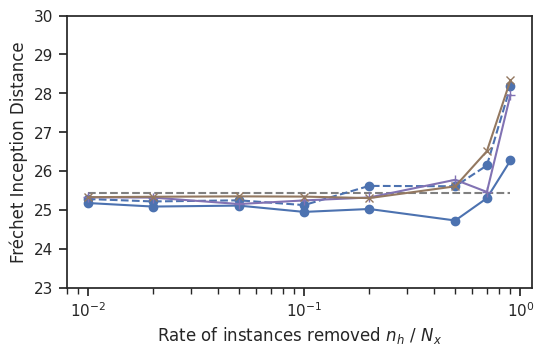

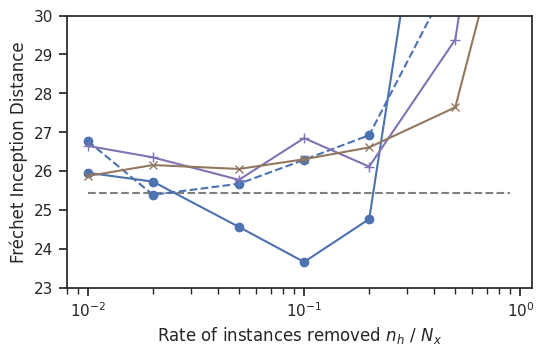

In [ ]:
idxs_removal_rates = np.arange(len(removal_rates))[3:]

# figures
figs, axes = zip(plt.subplots(figsize=(6, 4)), plt.subplots(figsize=(6, 4)))
xs = np.asarray(removal_rates)

for key, yss in d_ys.items():
    for ys, ax in zip(yss, axes):
        ys = np.array(ys)
        ax.plot(xs[idxs_removal_rates], ys[idxs_removal_rates],
                label=ConfigPlotCleansing.d_metric_rename[key],
                marker=ConfigPlotCleansing.d_metric_marker[key],
                linestyle=ConfigPlotCleansing.d_metric_style[key],
                color=ConfigPlotCleansing.d_metric_color[key],
                markersize=ConfigPlotCleansing.d_metric_markersize[key],
                )

ylim = (23, 30)

for fig, ax in zip(figs, axes):
    ax.set_xscale('log')
    ax.set_xlabel('Rate of instances removed ${n_{h} \ / \ N_x}$')
    ax.set_ylabel(ConfigPlotCleansing.d_eval_metric_rename[name_metric_eval])
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(mylogfmt))
    if ylim is not None:
        ax.set_ylim(*ylim)
    fig.subplots_adjust(bottom=0.2)
    

os.makedirs(OUT_DIR, exist_ok=True)
for fig, from_epoch in zip(figs, from_epochs):
    path = os.path.join(OUT_DIR, f"{name_metric_eval}_stylegan_clean_{n_epochs-from_epoch}epoch.{EXT_SAVEFIG}")
    fig.savefig(path, **KWARGS_SAVEFIG)
    print(f"Saved to {path}")
    

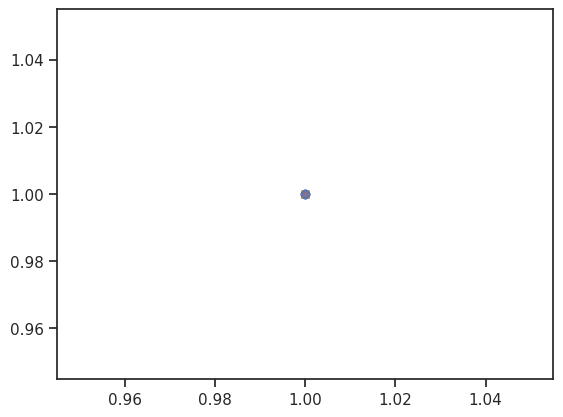

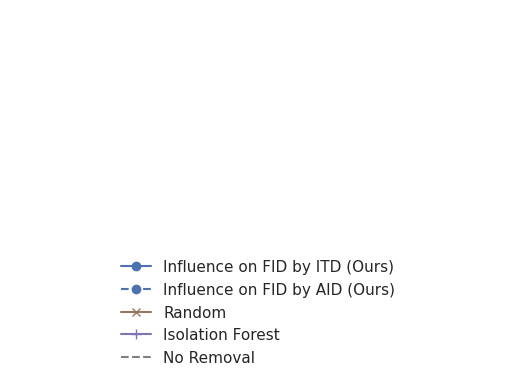

In [ ]:
selected_keys = [
    (Metric.FID, 'itd'),
    (Metric.FID, 'aid'),
    (Metric.RANDOM, 'itd'),
    (Metric.IF, 'itd'),
    'no_removal',
]

labels = [ConfigPlotCleansing.d_metric_rename[x] for x in selected_keys]
markers = [ConfigPlotCleansing.d_metric_marker[x] for x in selected_keys]
colors_ = [ConfigPlotCleansing.d_metric_color[x] for x in selected_keys]
styles = [ConfigPlotCleansing.d_metric_style[x] for x in selected_keys]
markersizes = [ConfigPlotCleansing.d_metric_markersize[x] for x in selected_keys]

legend = get_legend(labels=labels, markers=markers, colors=colors_, styles=styles, markersizes=markersizes, ncol=1)

bbox = get_tight_legend_bbox_inches(legend)
bbox = bbox.from_extents(bbox.xmin, bbox.ymin, bbox.xmax, bbox.ymax * 1.02)  # Increase the height by 20%

legend.figure.savefig(os.path.join(OUT_DIR, f"legends_cleansing.{EXT_SAVEFIG}"), dpi="figure", bbox_inches=bbox)
